In [1]:
import sys

sys.path.append("/home/alberto/UnReflectAnything/")
import torch
from rich import print

from dataset.rgbp import POLARGB_Dataset, SCARED_Dataset
from utilities.visualization import panelize, rgb

%load_ext autoreload
%autoreload 2    

KeyboardInterrupt: 

In [2]:
from polar_highlighter import PolarHighlighter, get_soft_highlight_map
ph = PolarHighlighter(height=448, width=448).cuda()


Some weights of DPTForDepthEstimation were not initialized from the model checkpoint at Intel/dpt-large and are newly initialized: ['neck.fusion_stage.layers.0.residual_layer1.convolution1.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution1.weight', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


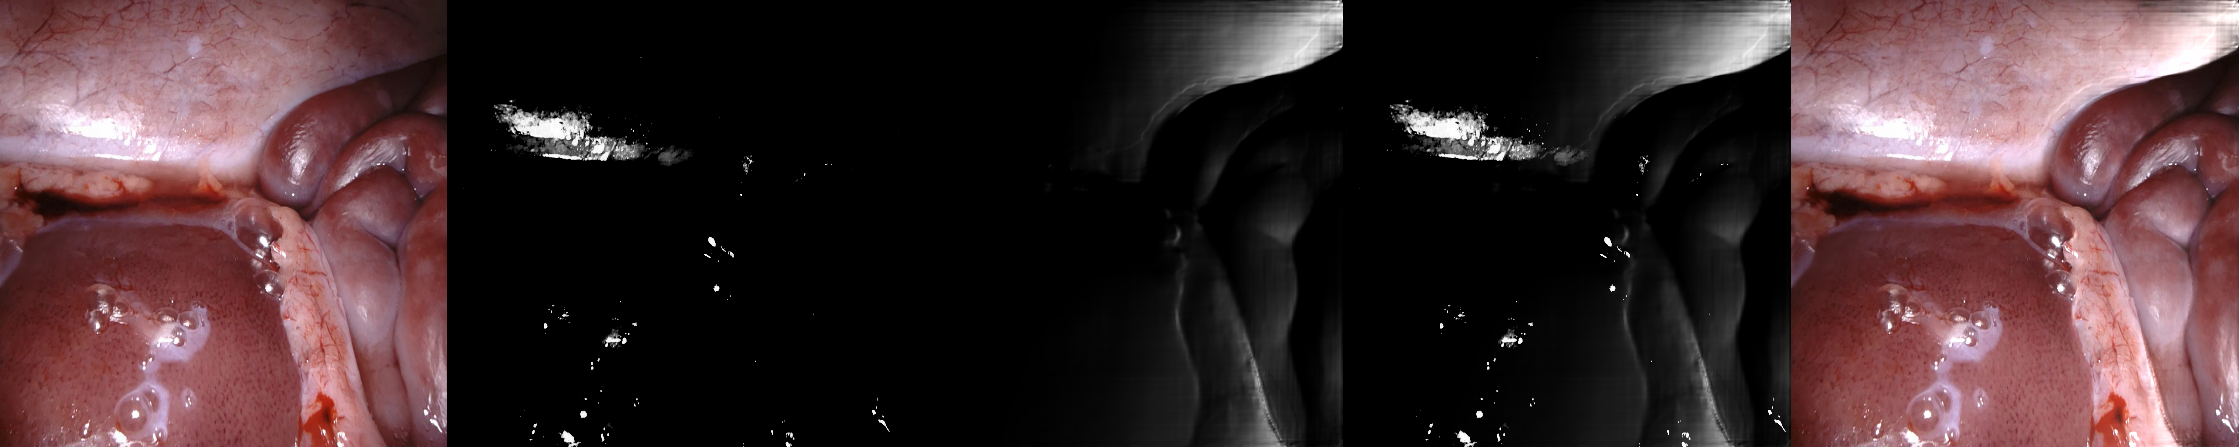

In [3]:

dataset = SCARED_Dataset(
    root_dir="/$DATASET_DIR/SCARED/",
    # scene_names=["scene01"],
    target_size=[448, 448],
    resize_mode="resize",
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break

image = batch["rgb"].cuda()
# pol = torch.cat([batch["S0"], batch["S1"], batch["S2"]], dim=1).cuda()
intrinsic = batch["intrinsics"].cuda()
intrinsic_res = intrinsic.clone()
intrinsic_res[0, 0, 0] = intrinsic[0, 0, 0] * 448 / 1140
intrinsic_res[0, 1, 1] = intrinsic[0, 1, 1] * 448 / 892
intrinsic_res[0, 0, 2] = intrinsic[0, 0, 2] * 448 / 1140
intrinsic_res[0, 1, 2] = intrinsic[0, 1, 2] * 448 / 892

result_ph = ph(
    rgb=image,
    intrinsic=intrinsic_res,
    shininess=4,
    ks=1.0,
)

# Test the function
soft_highlight_map = get_soft_highlight_map(image, threshold=0.8)
combined_highlights = result_ph["highlight"] + soft_highlight_map

# Use the weighted combination for better control
result_ph["highlight_both"] = combined_highlights.clamp(0,1)

rgb(
    panelize(
        rgb(image, resize=(448, 448), as_tensor=True),
        rgb(soft_highlight_map[0, 0], resize=(448, 448), as_tensor=True,colormap="gray"),
        rgb(result_ph["highlight"][0], resize=(448, 448), colormap="gray", as_tensor=True),
        rgb(result_ph["highlight_both"][0], resize=(448, 448), colormap="gray", as_tensor=True),
        rgb(result_ph["rgb_highlighted"][0], resize=(448, 448), as_tensor=True),
    )
)


In [ ]:
from dataset.highlight import HighlightDataset
from dataset.mono3d_dataset import SCARED
import os
purescared = HighlightDataset(
    SCARED(
        # There are 10 frames of SCARED in the dataset/sample_datasets/SCARED/ directory
        path=os.path.expandvars("$DATASET_DIR/SCARED/"),
        vids=SCARED.videonames(),
    ),
    brightness_threshold=0.9,
    rect_size=(384, 384),
    return_mask=True,
    return_rect=True,
)

batch= purescared[0]


FileNotFoundError: [Errno 2] No such file or directory: '/anvme/workspace/v120bb18-unreflectanything/datasets/SCARED/v1/frame/000003.png'

In [23]:
448*448

200704

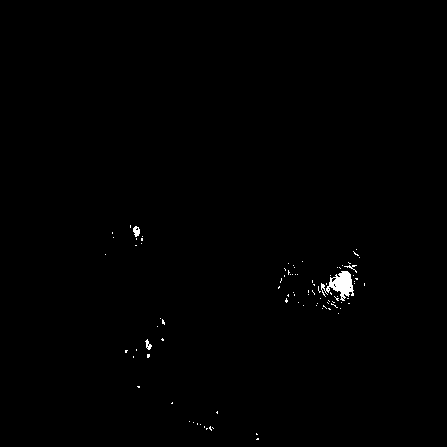

In [18]:
rgb(is_highlight.int(),colormap="gray")

In [10]:
loss = UnReflectLoss(
).cuda()

input_data = {
    "diffuse": batch["rgb"].cuda(),
    "rgb": result_ph["rgb_highlighted"].cuda(),
    "specular": batch["specular"].cuda(),
    "highlight": result_ph["highlight"].cuda()#.repeat(1, 4, 1, 1),
    }
decomposition = model(input_data)
# decomposition["diffuse"] = input_data["diffuse"].clone()
# decomposition["highlight"] = input_data["highlight"].clone()

lossv = loss(decomposition, input_data)
print("Decomposition")
print([{k: (v.shape,v.min().item(),v.max().item()) for k, v in decomposition.items()}])

print("Input data")
print([{k: (v.shape,v.min().item(),v.max().item()) for k, v in input_data.items()}])
print("Loss")
print([{k: v for k, v in lossv.items()}])


Decomposition

[
    {
        'diffuse': (torch.Size([1, 3, 448, 448]), 0.47916272282600403, 0.5319568514823914),
        'highlight': (torch.Size([1, 1, 448, 448]), 0.46259036660194397, 0.4754379391670227)
    }
]

Input data

[
    {
        'diffuse': (torch.Size([1, 3, 448, 448]), 0.06486582010984421, 1.0),
        'rgb': (torch.Size([1, 3, 448, 448]), 0.06486582010984421, 1.0),
        'specular': (torch.Size([1, 3, 448, 448]), 0.0, 0.0),
        'highlight': (torch.Size([1, 1, 448, 448]), 0.0, 1.0)
    }
]

Loss

[
    {
        'Diffuse': tensor(0.4675, device='cuda:0', grad_fn=<AddBackward0>),
        'HighlightRegression': tensor(0.6537, device='cuda:0', grad_fn=<AddBackward0>),
        'Decomposition': tensor(1.1213, device='cuda:0', grad_fn=<AddBackward0>),
        'Reconstruction': tensor(1.0011, device='cuda:0', grad_fn=<AddBackward0>),
        'AlphaReg': 0.0,
        'total': tensor(1.6218, device='cuda:0', grad_fn=<AddBackward0>)
    }
]

In [ ]:
rgb()

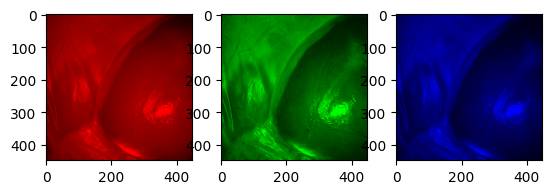

In [ ]:
import matplotlib.pyplot as plt

plt.subplot(1, 3, 1)
plt.imshow(
    torch.cat(
        [
            input_data["rgb"][:, 0],
            torch.zeros_like(input_data["rgb"][:, 0]),
            torch.zeros_like(input_data["rgb"][:, 0]),
        ]
    )
    .permute(1, 2, 0)
    .detach()
    .cpu()
)
torch.colo
plt.subplot(1, 3, 2)
plt.imshow(
    torch.cat(
        [
            torch.zeros_like(input_data["rgb"][:, 0]),
            input_data["rgb"][:, 1],
            torch.zeros_like(input_data["rgb"][:, 0]),
        ]
    )
    .permute(1, 2, 0)
    .detach()
    .cpu()
)
torch.colo
plt.subplot(1, 3, 3)
plt.imshow(
    torch.cat(
        [
            torch.zeros_like(input_data["rgb"][:, 2]),
            torch.zeros_like(input_data["rgb"][:, 0]),
            input_data["rgb"][:, 1],
        ]
    )
    .permute(1, 2, 0)
    .detach()
    .cpu()
)
torch.colo
plt.show()


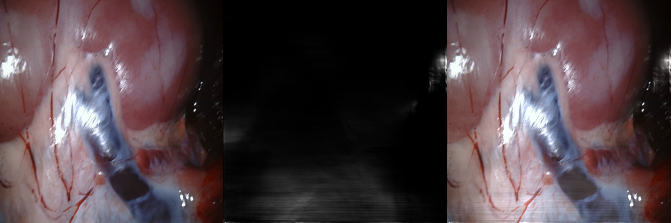

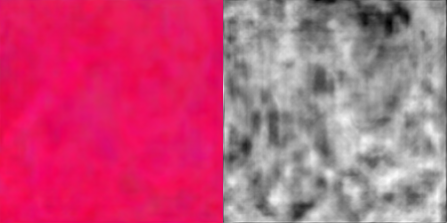

In [5]:
rgb(panelize(
    rgb(input_data["diffuse"][0].detach(), resize=(224, 224), as_tensor=True),
    rgb(input_data["highlight"][0].detach(), resize=(224, 224), as_tensor=True,colormap="gray"),
    rgb(input_data["rgb"][0].detach(), resize=(224, 224), as_tensor=True),
))
rgb(panelize(
    rgb(decomposition["diffuse"][0].detach(), resize=(224, 224), as_tensor=True),
    rgb(decomposition["highlight"][0].detach(), resize=(224, 224), as_tensor=True,colormap="gray"),
))

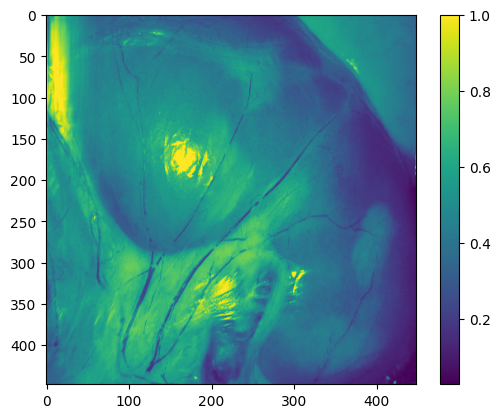

In [10]:
import matplotlib.pyplot as plt
plt.imshow(input_data["rgb"][0].mean(dim=0).detach().cpu()
        )
plt.colorbar()
plt.show()

In [ ]:
out = distill(batch)
print(out["specular"].shape)
print(out["diffuse"].shape)
print(out["highlight"].shape)
print([l.shape for l in out["rgb_tokens"]])

In [ ]:
out = model(batch)
print(out["specular"].shape)
print(out["diffuse"].shape)
print(out["highlight"].shape)
print([l.shape for l in out["rgb_tokens"]])
print([l.shape for l in out["pol_tokens"]])
print([l.shape for l in out["cross_tokens"]])

In [ ]:
model.dinov3.config

In [ ]:
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            as_tensor=True,
            resize=(892, 1140),
            colormap="gray",
        ),
        panelize(
            panelize(
                rgb(
                    0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(892 // 2, 1140 // 2),
                ),
                rgb(
                    0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(892 // 2, 1140 // 2),
                ),
                rgb(
                    0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(892 // 2, 1140 // 2),
                ),
                rgb(
                    0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(892 // 2, 1140 // 2),
                ),
            ),
            panelize(
                rgb(
                    0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(892 // 2, 1140 // 2),
                ),
                rgb(
                    0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(892 // 2, 1140 // 2),
                ),
                rgb(
                    0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(892 // 2, 1140 // 2),
                ),
                rgb(
                    0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                    as_tensor=True,
                    resize=(892 // 2, 1140 // 2),
                ),
            ),
            mode="vertical",
        ),
        resize_to_match=False,
    )
)

In [ ]:
import yaml
from dotmap import DotMap

from projections import ReflectionWarp

# Initialize the module
height, width = batch["rgb"].shape[2:]
reflection_warp = ReflectionWarp(height, width)
reflection_warp = reflection_warp.cuda()  # Move to GPU


light_color = torch.tensor([1.0, 0.8, 0.8]).cuda()  # Warm light

from pipelines.depth.depth import DepthPipeline

CONFIG_PATH = "../config.yaml"
with open(CONFIG_PATH, "r") as f:
    config_yaml = yaml.safe_load(f)
    config_parameters = config_yaml["parameters"]
    config_training_dict = {
        k: v.get("value") for k, v in config_parameters.items() if v is not None
    }
    config = DotMap(config_training_dict)
    config.IMAGE_HEIGHT = height
    config.IMAGE_WIDTH = width
depthPipeline = DepthPipeline(config, model="", device="cuda")

light_position = torch.randn((1, 3)) * config.DEPTH_SCALE_FACTOR / 2
light_position[0, 1:] = -torch.abs(light_position[0, 1:])
torch.cuda.empty_cache()
with torch.no_grad():
    depth_map = depthPipeline.depth(batch["rgb"].cuda())

# Call with point light
result = reflection_warp.forward_point_light(
    source_image=batch["rgb"][0:1].cuda(),
    depth_map=depth_map[0:1].cuda(),
    camera_intrinsics=batch["intrinsics"].cuda()[0:1],
    camera_pose=torch.eye(4)
    .unsqueeze(0)
    .repeat(batch["rgb"].shape[0], 1, 1)
    .cuda()[0:1],
    light_position=light_position.cuda(),
    light_intensity=100.0,
    light_color=light_color.cuda(),
    surface_roughness=0.1,  # Slightly rough surface
    reflection_strength=0.9,  # Strong reflections
    return_mask=True,
    return_artifacts=True,
)
rgb(
    panelize(
        rgb(result["warped"][0], as_tensor=True),
        rgb(result["reflection_only"][0], colormap="gray", as_tensor=True),
        rgb(batch["rgb"][0], as_tensor=True),
    )
)

In [ ]:
result.keys()

In [ ]:
(
    batch["rgb"].shape,
    depth_map.shape,
    batch["intrinsics"].shape,
    torch.eye(4).unsqueeze(0).repeat(batch["rgb"].shape[0], 1, 1).cuda().shape,
)

In [ ]:
result = reflection_warp.forward_point_light(
    source_image=batch["rgb"][0:1].cuda(),
    depth_map=depth_map[0:1].cuda(),
    camera_intrinsics=batch["intrinsics"].cuda()[0:1],
    camera_pose=torch.eye(4)
    .unsqueeze(0)
    .repeat(batch["rgb"].shape[0], 1, 1)
    .cuda()[0:1],
    light_position=light_position.cuda(),
    light_intensity=100.0,
    light_color=light_color.cuda(),
    surface_roughness=0.1,  # Slightly rough surface
    reflection_strength=0.9,  # Strong reflections
    return_mask=True,
    return_artifacts=True,
)

In [ ]:
rgb(batch["rgb"][0])
rgb(depth_map[0], colormap="jet")